# Model Comparison v2: Precise WB2 Climatology + Extended Diagnostics

Обновлённое сравнение Pangu-Weather 6h / Aurora / Stormer на 96-init кампании (2024-2025), теперь с:
- **Точной климатологией WeatherBench2** (day-of-year x hour, 1990-2019) вместо нашей грубой месячной аппроксимации
- **RMSE, ACC** — как раньше, но точнее
- **Bias** — систематическая ошибка (не только модуль)
- **Variance ratio** — диагностика "blurring" (std прогноза / std правды — если <1, модель теряет изменчивость/сглаживает)
- **Corr(прогноз, климатология) vs Corr(правда, климатология)** — регрессирует ли модель к среднему сильнее, чем реальная погода
- **Zonal power spectrum** — стандартная диагностика из статей (мощность по масштабам, прогноз vs правда)

Сырые прогнозы закэшированы (`results/campaign_<model>_predictions/`) — метрики можно пересчитать без повторного прогона моделей.


In [1]:
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 110

MODELS = ['pangu6', 'aurora', 'stormer']
MODEL_LABELS = {'pangu6': 'Pangu-Weather (6h)', 'aurora': 'Aurora', 'stormer': 'Stormer'}
MODEL_COLORS = {'pangu6': '#2980b9', 'aurora': '#c0392b', 'stormer': '#27ae60'}
RESULTS_ROOT = os.path.expanduser('~/weather-interpretability/results')

VARIABLES_TO_PLOT = [
    ('mean_sea_level_pressure', 'MSLP'),
    ('2m_temperature', 'T2M'),
    ('geopotential@500hPa', 'Z@500hPa'),
    ('u_component_of_wind@850hPa', 'U@850hPa'),
]


## 1. Загрузка результатов кампании


In [2]:
all_runs = {}
for model in MODELS:
    files = sorted(glob.glob(os.path.join(RESULTS_ROOT, f'campaign_{model}', '*.pkl')))
    runs = []
    for fpath in files:
        with open(fpath, 'rb') as f:
            runs.append(pickle.load(f))
    all_runs[model] = runs
    print(f'{model}: {len(runs)} init runs loaded')


pangu6: 96 init runs loaded


aurora: 95 init runs loaded


stormer: 96 init runs loaded


In [3]:
def aggregate_metric(runs, metric_key, variable):
    """Average a per-lead metric across all init dates."""
    by_lead = {}
    for run in runs:
        for lead, step_metrics in zip(run['lead_hours'], run[metric_key]):
            if variable in step_metrics:
                by_lead.setdefault(lead, []).append(step_metrics[variable])
    leads = sorted(by_lead.keys())
    means = [np.mean(by_lead[l]) for l in leads]
    return leads, means


def plot_grid(metric_key, ylabel, title_suffix, filename, hline=None):
    fig, axes = plt.subplots(1, len(VARIABLES_TO_PLOT), figsize=(6 * len(VARIABLES_TO_PLOT), 5))
    for ax, (var_key, var_label) in zip(axes, VARIABLES_TO_PLOT):
        for model in MODELS:
            leads, means = aggregate_metric(all_runs[model], metric_key, var_key)
            if not leads:
                continue
            ax.plot(leads, means, marker='o', label=MODEL_LABELS[model], color=MODEL_COLORS[model])
        if hline is not None:
            ax.axhline(hline, color='gray', linestyle=':', linewidth=1)
        ax.set_xlabel('Lead time (hours)')
        ax.set_ylabel(ylabel)
        ax.set_title(var_label)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    fig.suptitle(title_suffix, y=1.03, fontsize=11)
    plt.tight_layout()
    os.makedirs('figures/06_climatology_correlation', exist_ok=True)
    plt.savefig(f'figures/06_climatology_correlation/{filename}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 2. RMSE и ACC (с точной климатологией)


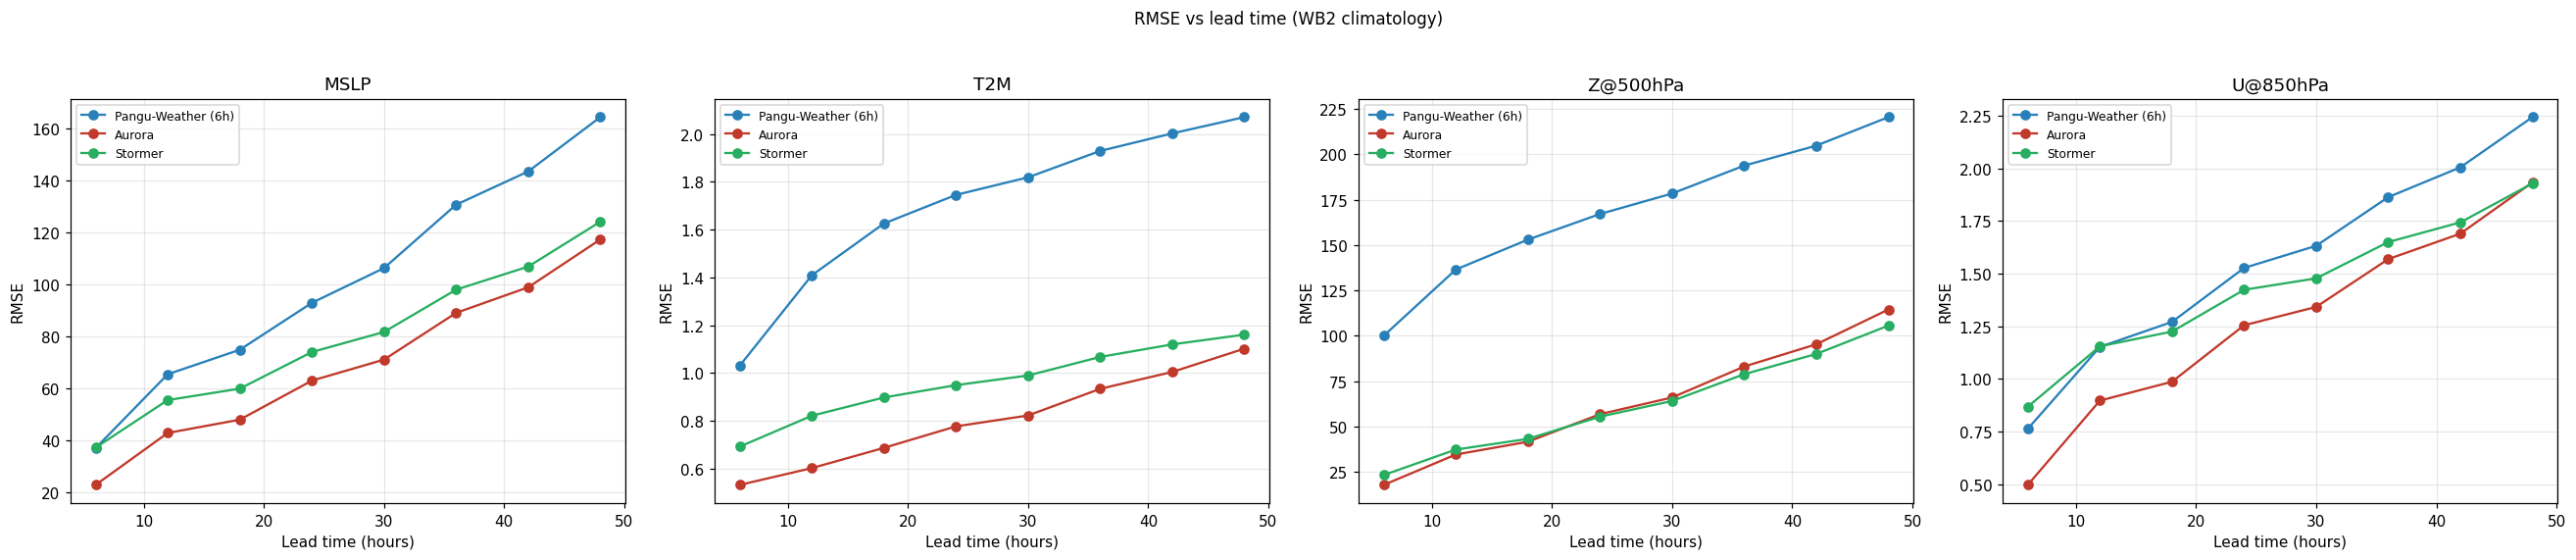

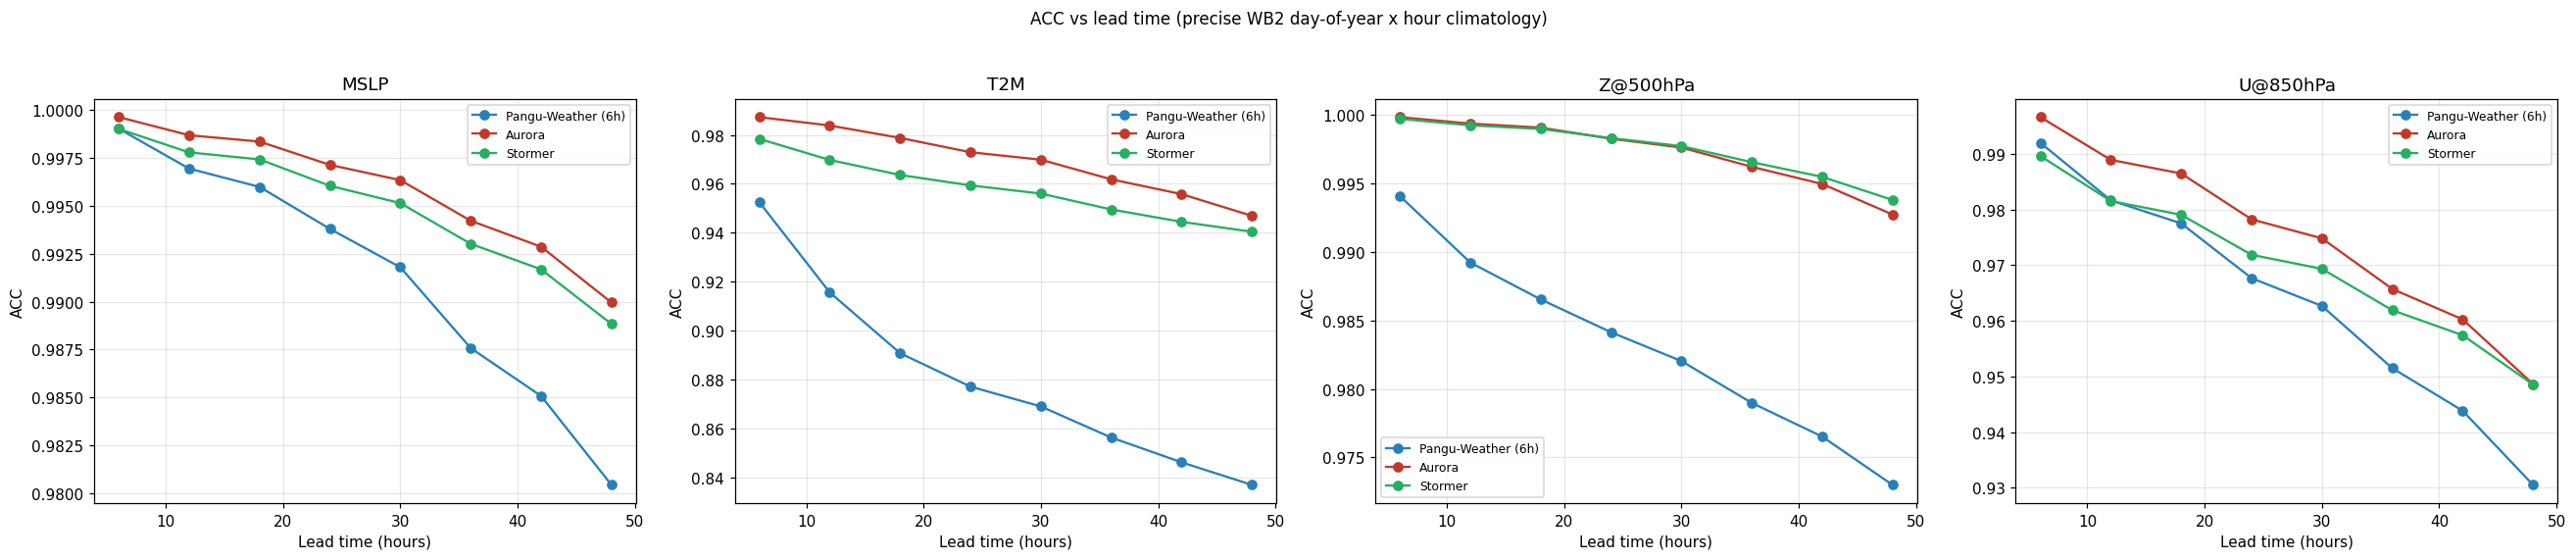

In [4]:
plot_grid('rmse', 'RMSE', 'RMSE vs lead time (WB2 climatology)', 'rmse_vs_leadtime_v2')
plot_grid('acc', 'ACC', 'ACC vs lead time (precise WB2 day-of-year x hour climatology)', 'acc_vs_leadtime_v2')


## 3. Bias — систематическая ошибка

В отличие от RMSE (модуль ошибки), bias показывает направление: систематически завышает или занижает модель.
Ноль — нет систематического смещения (случайная ошибка в обе стороны).


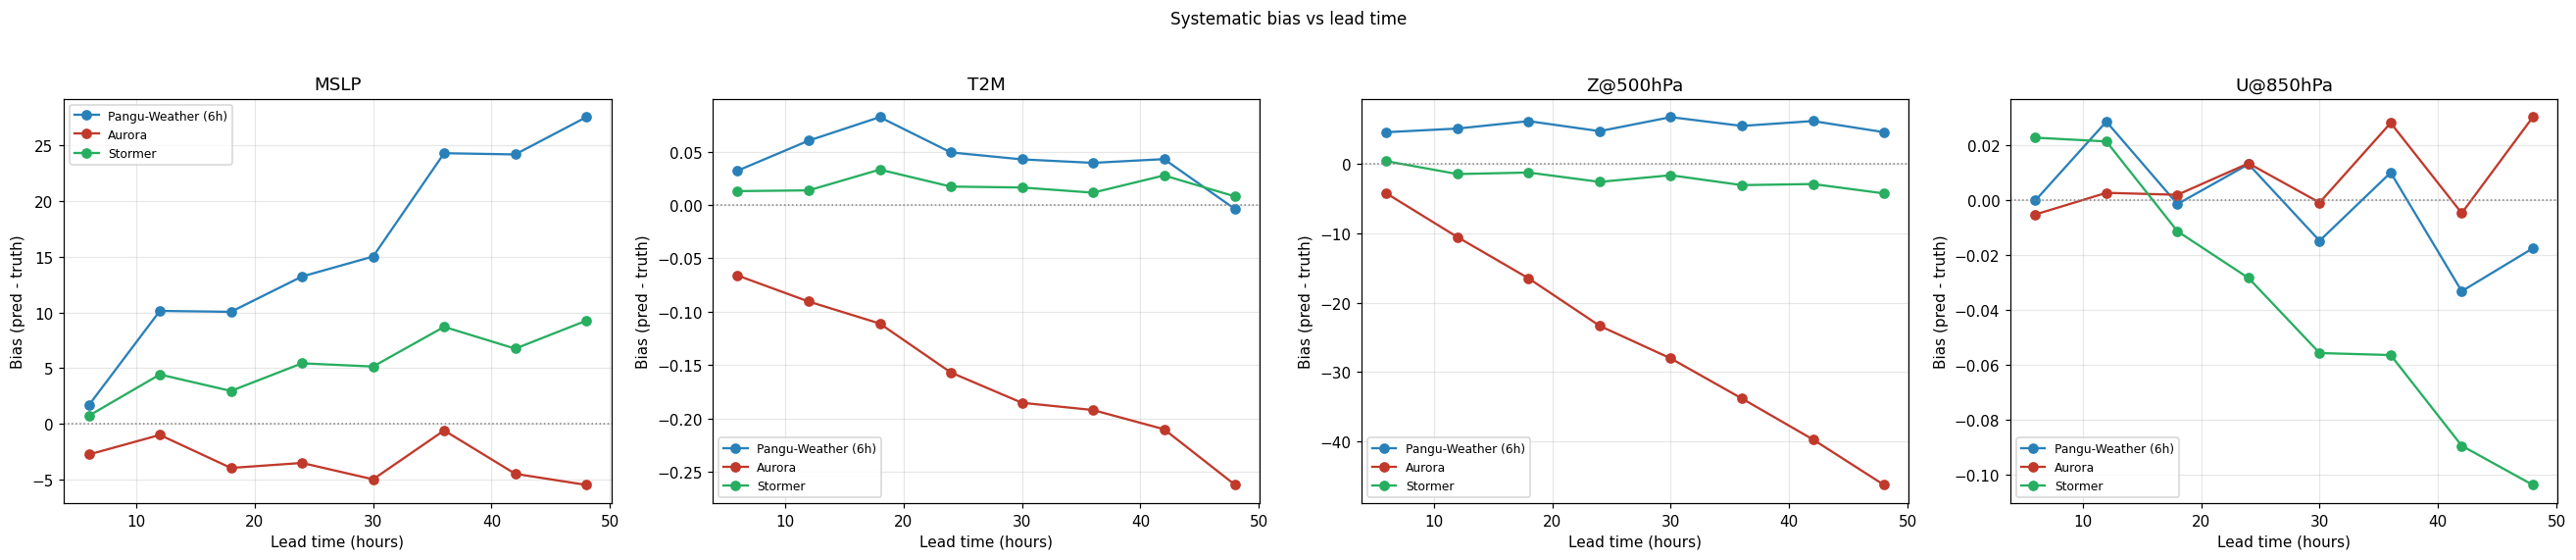

In [5]:
plot_grid('bias', 'Bias (pred - truth)', 'Systematic bias vs lead time', 'bias_vs_leadtime', hline=0)


## 4. Variance ratio — диагностика "blurring"

std(прогноз) / std(правда). Если <1 и падает с lead time — модель теряет пространственную изменчивость
(сглаживается, регрессирует к среднему) — известная проблема детерминистических AI-моделей погоды.
Пунктир на 1.0 — идеал (та же изменчивость, что и в реальности).


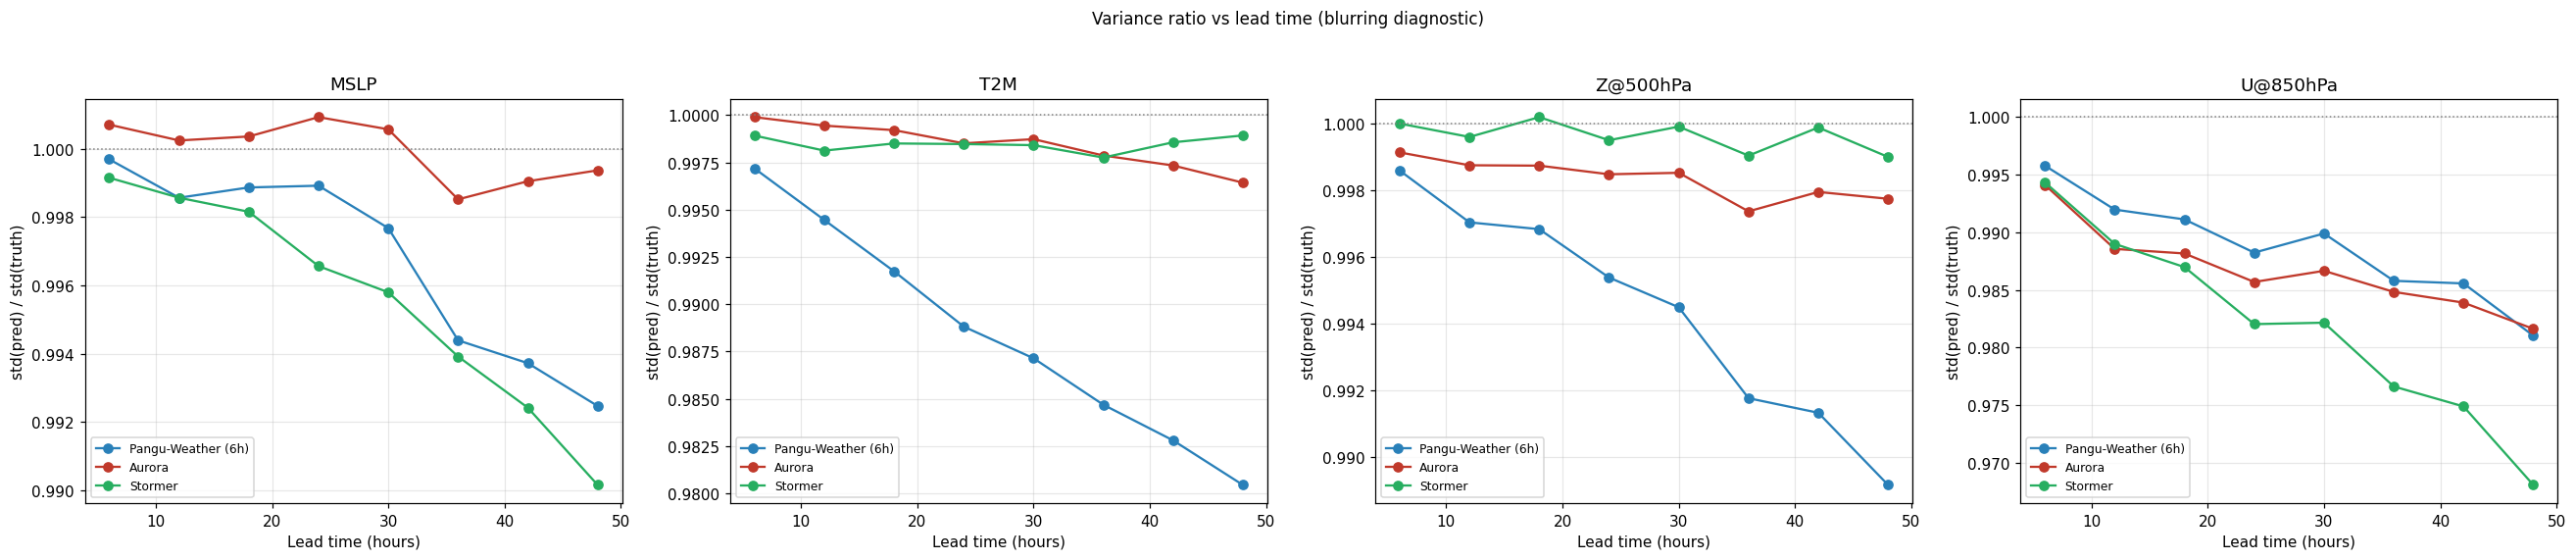

In [6]:
plot_grid('variance_ratio', 'std(pred) / std(truth)', 'Variance ratio vs lead time (blurring diagnostic)',
           'variance_ratio_vs_leadtime', hline=1.0)


## 5. Corr(прогноз, климатология) vs Corr(правда, климатология)

Если корреляция прогноза с климатологией растёт быстрее/выше, чем у реальных данных на тот же момент —
модель "скатывается" к климатологическому среднему сильнее, чем происходит в реальности (регрессия к среднему,
потеря экстремумов). Совпадающие линии = модель корректно сохраняет реальную степень "необычности" погоды.


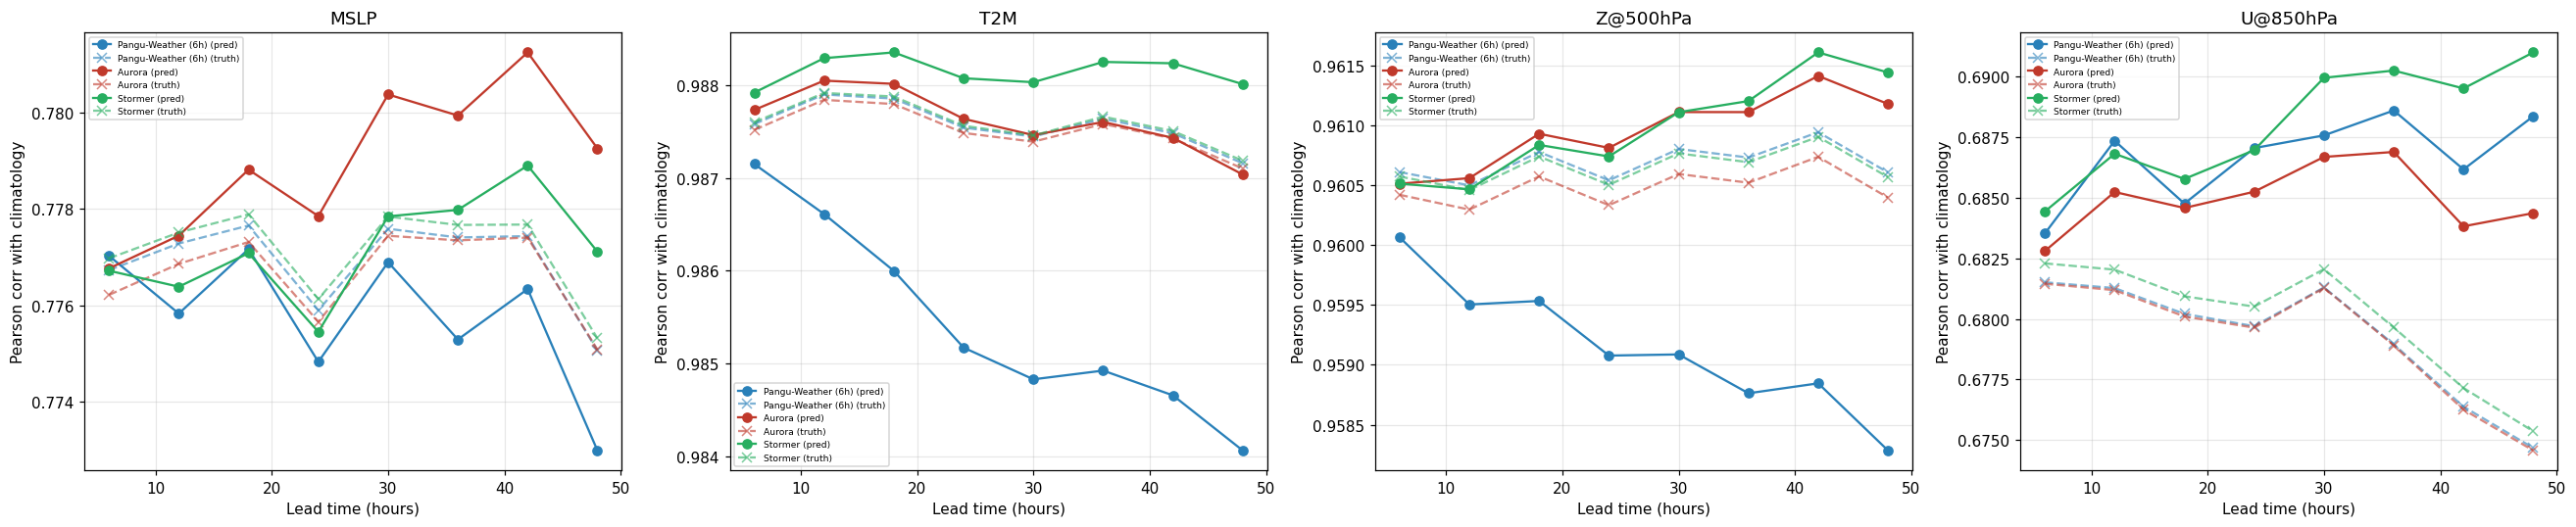

In [7]:
fig, axes = plt.subplots(1, len(VARIABLES_TO_PLOT), figsize=(6 * len(VARIABLES_TO_PLOT), 5))
for ax, (var_key, var_label) in zip(axes, VARIABLES_TO_PLOT):
    for model in MODELS:
        leads, pred_means = aggregate_metric(all_runs[model], 'corr_pred_clim', var_key)
        _, truth_means = aggregate_metric(all_runs[model], 'corr_truth_clim', var_key)
        if not leads:
            continue
        ax.plot(leads, pred_means, marker='o', label=f'{MODEL_LABELS[model]} (pred)',
                color=MODEL_COLORS[model], linestyle='-')
        ax.plot(leads, truth_means, marker='x', label=f'{MODEL_LABELS[model]} (truth)',
                color=MODEL_COLORS[model], linestyle='--', alpha=0.6)
    ax.set_xlabel('Lead time (hours)')
    ax.set_ylabel('Pearson corr with climatology')
    ax.set_title(var_label)
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/06_climatology_correlation/corr_with_climatology_vs_leadtime.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Насколько "необычна" исходная погода (input vs климатология)

Corr(input, климатология на init) на каждую из 96 дат — распределение по всей кампании. Низкие значения =
аномальные/интересные синоптические случаи, высокие = типичная погода для этого дня года.


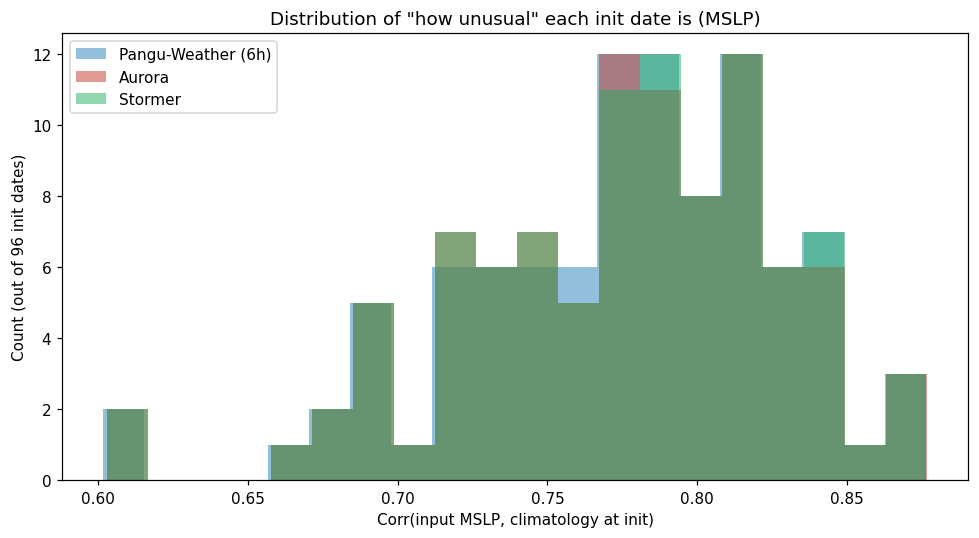

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for model in MODELS:
    values = [run['input_corr_clim']['mean_sea_level_pressure'] for run in all_runs[model]
              if 'mean_sea_level_pressure' in run['input_corr_clim']]
    ax.hist(values, bins=20, alpha=0.5, label=MODEL_LABELS[model], color=MODEL_COLORS[model])
ax.set_xlabel('Corr(input MSLP, climatology at init)')
ax.set_ylabel('Count (out of 96 init dates)')
ax.set_title('Distribution of "how unusual" each init date is (MSLP)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06_climatology_correlation/input_corr_clim_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Zonal power spectrum — прогноз vs правда

Стандартная диагностика "blurring" из литературы по AI-моделям погоды: мощность сигнала по зональным волновым
числам (масштабам). Схлопывание мощности на высоких волновых числах (мелкие масштабы) с ростом lead time —
известный артефакт AI-моделей, обученных на MSE-подобных функциях потерь.


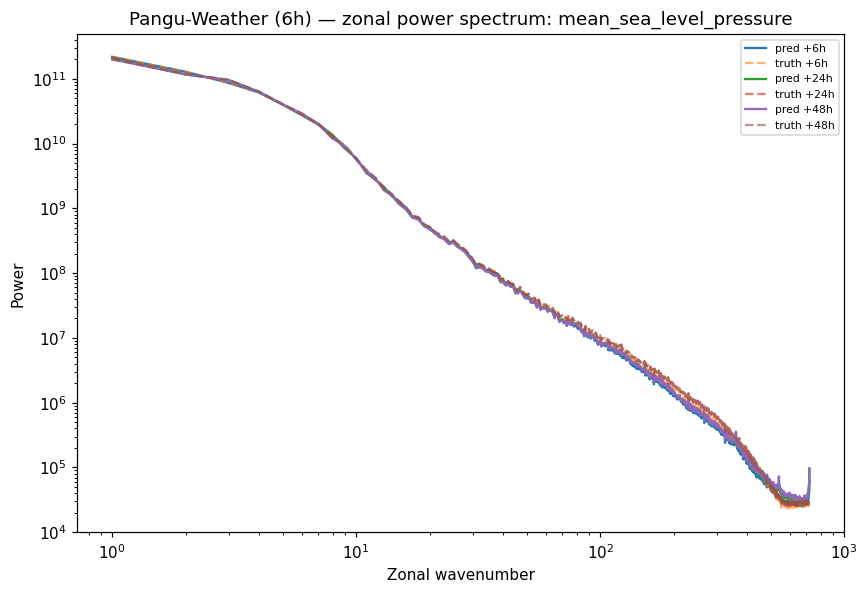

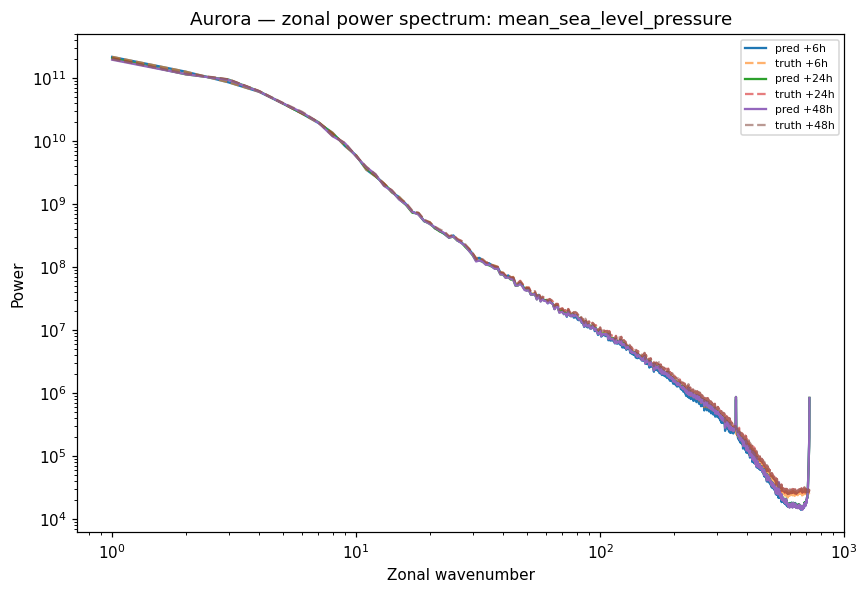

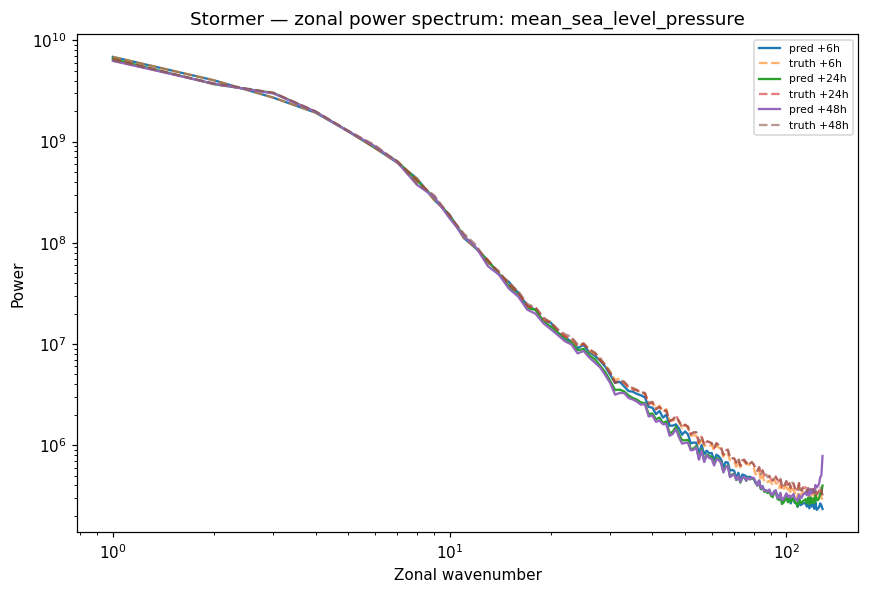

In [9]:
def plot_spectrum(model, variable, leads_to_show=(6, 24, 48)):
    runs = all_runs[model]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for lead in leads_to_show:
        pred_specs, truth_specs = [], []
        for run in runs:
            if lead not in run['lead_hours']:
                continue
            idx = run['lead_hours'].index(lead)
            if variable in run['spectral']['pred'][idx]:
                pred_specs.append(run['spectral']['pred'][idx][variable])
                truth_specs.append(run['spectral']['truth'][idx][variable])
        if not pred_specs:
            continue
        mean_pred = np.mean(pred_specs, axis=0)
        mean_truth = np.mean(truth_specs, axis=0)
        wavenumbers = np.arange(len(mean_pred))
        ax.loglog(wavenumbers[1:], mean_pred[1:], label=f'pred +{lead}h', linestyle='-')
        ax.loglog(wavenumbers[1:], mean_truth[1:], label=f'truth +{lead}h', linestyle='--', alpha=0.6)
    ax.set_xlabel('Zonal wavenumber')
    ax.set_ylabel('Power')
    ax.set_title(f'{MODEL_LABELS[model]} — zonal power spectrum: {variable}')
    ax.legend(fontsize=7)
    plt.tight_layout()
    safe_name = variable.replace('@', '_')
    plt.savefig(f'figures/06_climatology_correlation/spectrum_{model}_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model in MODELS:
    plot_spectrum(model, 'mean_sea_level_pressure')


## 8. Наблюдения

*(Заполнить после просмотра: у какой модели variance ratio падает сильнее с lead time — та модель сильнее
"размывает" прогноз; совпадают ли corr_pred_clim/corr_truth_clim — если prediction расходится с truth в сторону
климатологии, модель регрессирует к среднему; смотрим на спектр — у какой модели раньше схлопывается мощность
на мелких масштабах.)*
